In [1]:
!kaggle datasets download vipullrathod/fish-market

Dataset URL: https://www.kaggle.com/datasets/vipullrathod/fish-market
License(s): CC0-1.0
100% 2.38k/2.38k [00:00<00:00, 4.79MB/s]



In [2]:
!unzip fish-market.zip

Archive:  fish-market.zip
  inflating: Fish.csv                


In [3]:
import pandas as pd

In [4]:
df = pd.read_csv('Fish.csv')
df.head()

,Species,Weight,Length1,Length2,Length3,Height,Width
0,Bream,242.0,23.2,25.4,30.0,11.5200,4.0200
1,Bream,290.0,24.0,26.3,31.2,12.4800,4.3056
2,Bream,340.0,23.9,26.5,31.1,12.3778,4.6961
3,Bream,363.0,26.3,29.0,33.5,12.7300,4.4555
4,Bream,430.0,26.5,29.0,34.0,12.4440,5.1340


In [5]:
df.isna().sum()

,0
Species,0
Weight,0
Length1,0
Length2,0
Length3,0
Height,0
Width,0


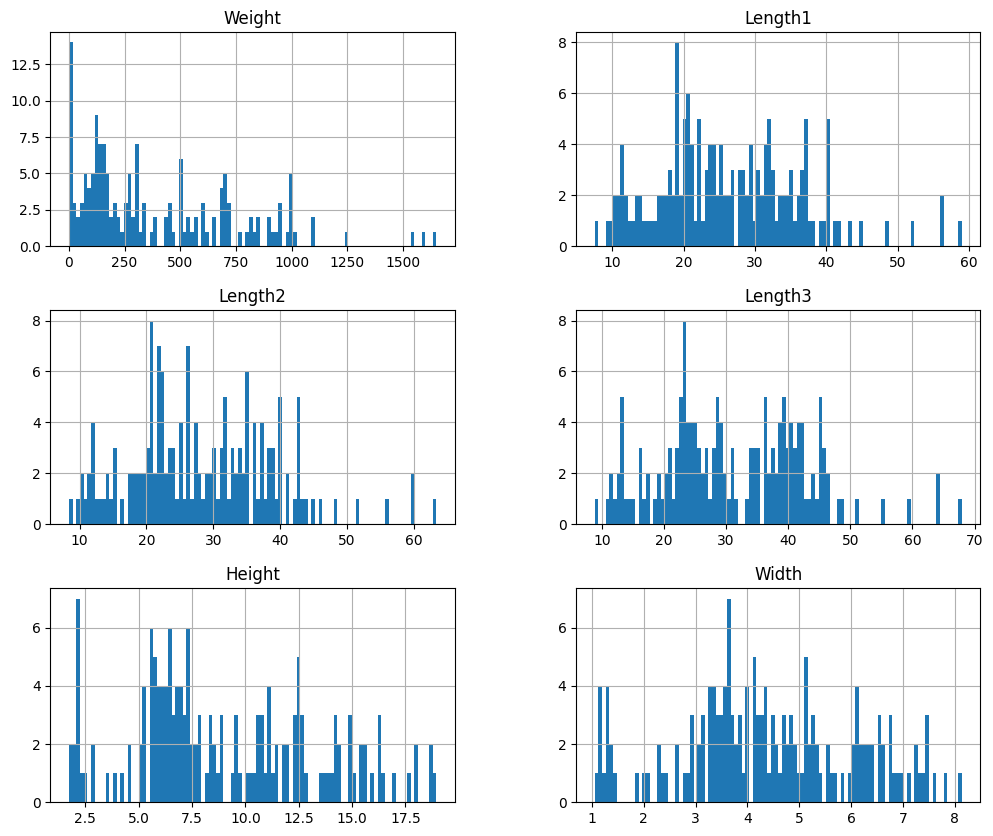

In [6]:
df.hist(figsize=(12,10), bins=100);

In [7]:
df.shape

(159, 7)

In [8]:
from sklearn.ensemble import IsolationForest
iso_f = IsolationForest(contamination=0.02)
iso1 = iso_f.fit_predict(df.drop(columns='Species'))
outliers = iso1 == -1
df = df.loc[~outliers,:]

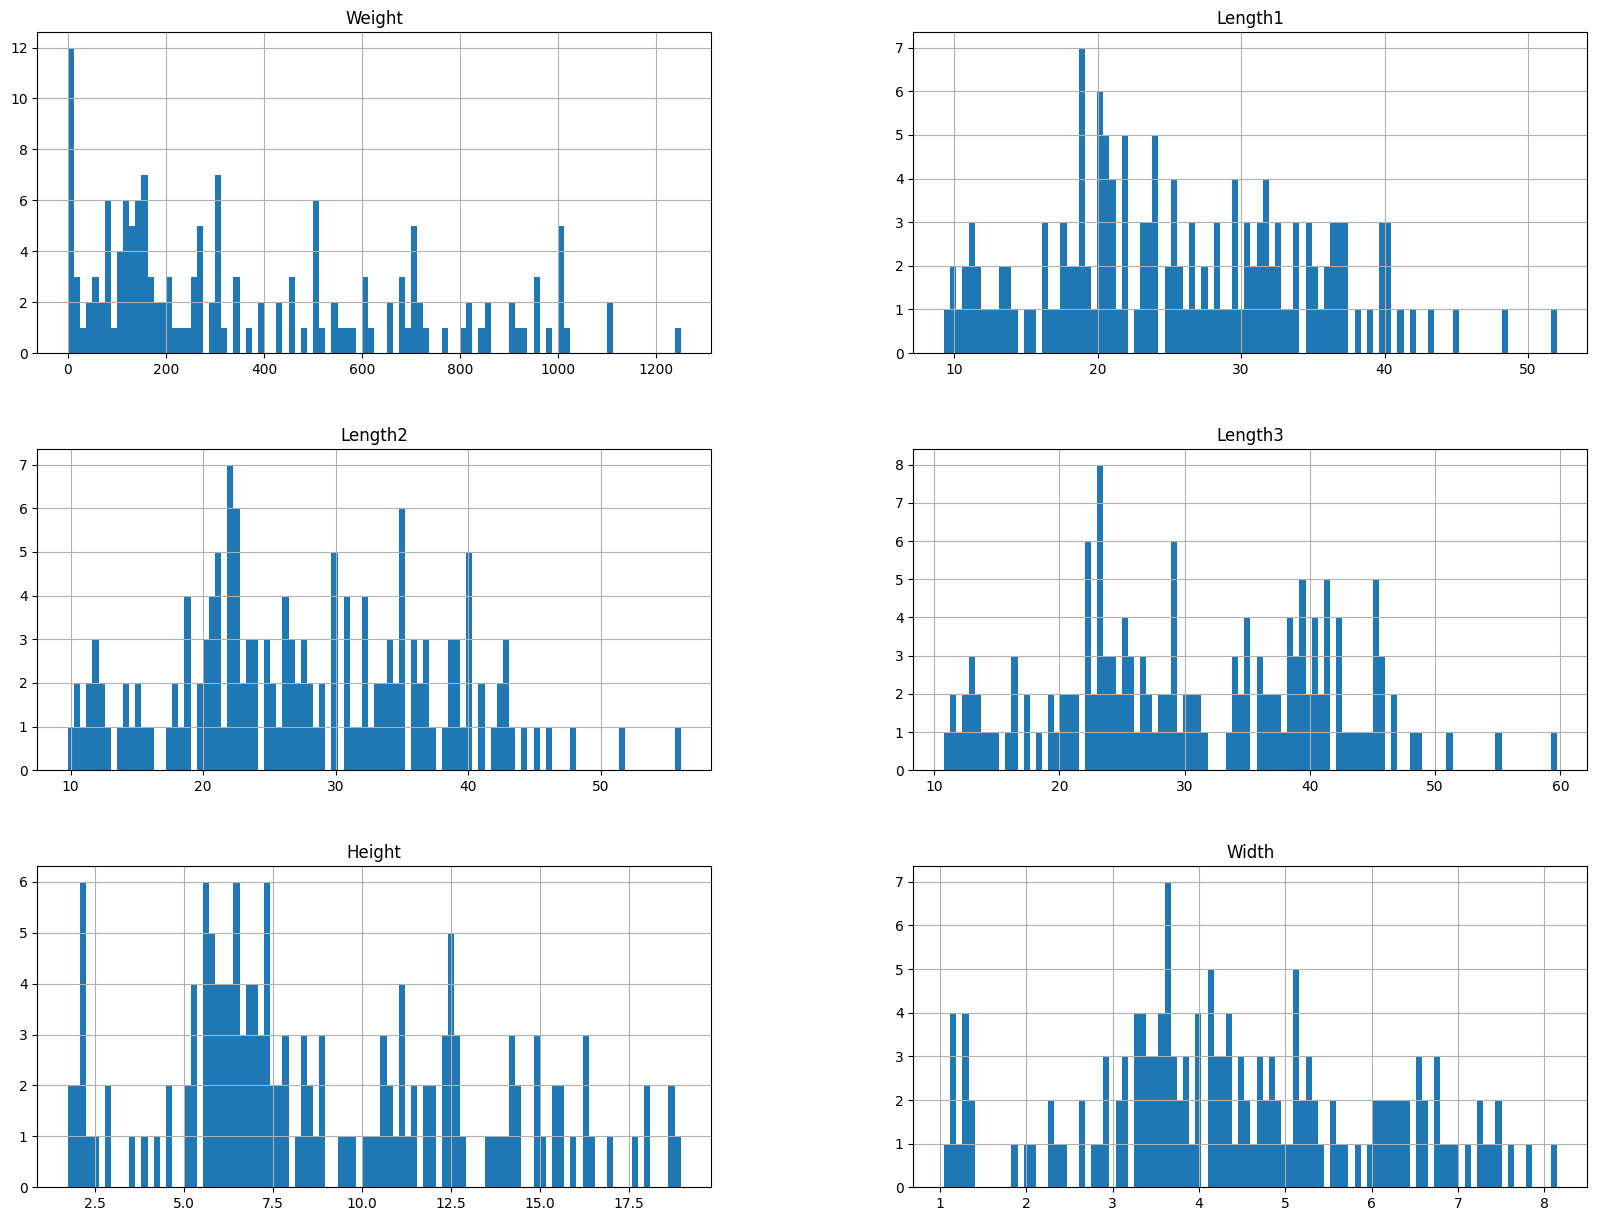

In [9]:
df.hist(bins=100, figsize=(20,15));

In [10]:
df['Species'].unique()

array(['Bream', 'Roach', 'Whitefish', 'Parkki', 'Perch', 'Pike', 'Smelt'],
      dtype=object)

In [11]:
X = df.drop(columns='Weight')
y = df['Weight']

In [13]:
X.select_dtypes(include='float').columns

Index(['Length1', 'Length2', 'Length3', 'Height', 'Width'], dtype='object')

In [14]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y ,test_size=0.2, random_state=42)

In [17]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler,OneHotEncoder
from sklearn.linear_model import LinearRegression
from sklearn.compose import ColumnTransformer

num_cols=['Length1', 'Length2', 'Length3', 'Height', 'Width']
cat_cols=['Species']

num_pipeline = Pipeline([
    ('scaler', StandardScaler())
])

cat_pipeline = Pipeline([
    ('encoder', OneHotEncoder())
])

preprocessing = ColumnTransformer([
    ('num', num_pipeline, num_cols),
    ('cat', cat_pipeline, cat_cols)
])

full_pipeline = Pipeline([
    ('preprocessing', preprocessing),
    ('model', LinearRegression())
])


full_pipeline.fit(X_train,y_train)
y_pred = full_pipeline.predict(X_test)

mean_absolute_error(y_test, y_pred), mean_squared_error(y_test, y_pred), r2_score(y_test, y_pred)

(46.13056323210421, 4292.421451560491, 0.9642446845281645)